<a href="https://colab.research.google.com/github/DACSS690C26/Homework_1/blob/main/hm1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Homework 1 DACSS690C
##Spatial Autocorrelation
##Patrick McGrath
###Summer 2026

Import and activate needed libraries

In [77]:
#Install needed Libraries
#!pip show pysal pandas geopandas libpysal esda
import geopandas as gpd
import pandas as pd
from libpysal.graph import Graph
from numpy.random import seed
seed(42)

Read Peru Map data from Github

In [78]:
#Pull needed data from GITHUB Repo
peru_link = "https://github.com/DACSS690C26/Homework_1/raw/main/PeruMaps.gpkg"
peru=gpd.read_file(peru_link,layer='good_geom')


Verify the map is projected

In [79]:
peru.crs.to_epsg(),\
peru.crs.is_projected, \
set(peru.geom_type)
#(5387, True, {'MultiPolygon'})
peru=peru.to_crs(5387)
#peru.DEPARTAMENTO.unique()#Lima

Keep the DEPARTAMENTO of 'LIMA'

In [80]:
lima=peru[peru['DEPARTAMENTO']=='Lima']
#lima.head()



Produce the LISA MAP using the normalized neighborhood  matrix (or weights matrix) using the QUEEN criterion

In [81]:
lima_queen=Graph.build_contiguity(lima,rook=False)

toWideMatrix=lambda g:pd.DataFrame(g.adjacency).unstack().fillna(0)

queen_lima_Matrix=toWideMatrix(lima_queen)
queen_lima_Matrix


#  "islands" may create trouble.
# Should you keep using a _contiguity_ approach, you may consider filtering those out
lima_queen.isolates

lima_queen=lima_queen.transform("r")

ylag = lima_queen.lag(lima["Educ_sec_comp2019_pct"])

lima=lima.assign(Educ_sec_comp2019_pct_lagged=ylag)


#lima.plot.scatter("Educ_sec_comp2019_pct","Educ_sec_comp2019_pct_lagged")

import esda # from pysal

MoranGlobal_HS = esda.Moran(lima['Educ_sec_comp2019_pct'], lima_queen)
MoranGlobal_HS.I,MoranGlobal_HS.p_sim


lisa = esda.Moran_Local(lima['Educ_sec_comp2019_pct'], lima_queen)

#lisa.plot(lima,crit_value=0.05,figsize=(10,13),legend=True)

In [82]:
# get the quadrants
lima['HS_lisa'] = lisa.get_cluster_labels(crit_value=0.05)
# see the count
lima['HS_lisa'].value_counts()

,count
HS_lisa,
Insignificant,103
High-High,39
Low-Low,23
High-Low,6


In [83]:
TheStats=["mean", "min", "max","var"]


# stats by the lisa cluster
grouped_stats = lima.groupby('HS_lisa')['Educ_sec_comp2019_pct'].agg(TheStats)

# stats for the entire, ungrouped column
global_stats = lima['Educ_sec_comp2019_pct'].agg(TheStats)

# Convert 'global_stats' (Series) to a DataFrame with an appropriate index name
global_stats_df = pd.DataFrame(global_stats).T
global_stats_df.index = ['Global/Total'] # simple but key

# Combine both
pd.concat([grouped_stats, global_stats_df])

,mean,min,max,var
High-High,78.426636,66.653554,89.215043,15.179261
High-Low,73.386075,68.601779,84.743374,34.726328
Insignificant,62.286290,16.477878,85.209470,184.903524
Low-Low,48.696294,12.358409,61.943082,167.241844
Global/Total,64.528993,12.358409,89.215043,221.040099


In [84]:
##knowing
lima['HS_lisa'].unique()

oldLabels=['Insignificant', 'Low-Low', 'High-High', 'High-Low', 'Low-High']
#oldLabels = ['Low-Low', 'Insignificant', 'High-Low', 'High-High']
# 3 will be at the middle
newLabels = ['3 no_pattern', '4 coldSpot','2 hotSpot','1 hotOutlier' , '5 coldOutlier']

labels = dict(zip(oldLabels, newLabels))

labels


{'Insignificant': '3 no_pattern',
 'Low-Low': '4 coldSpot',
 'High-High': '2 hotSpot',
 'High-Low': '1 hotOutlier',
 'Low-High': '5 coldOutlier'}

In [85]:


lima.replace({'HS_lisa':labels},inplace=True)

## see the count
lima['HS_lisa'].value_counts().sort_index()

,count
HS_lisa,
1 hotOutlier,6
2 hotSpot,39
3 no_pattern,103
4 coldSpot,23


<Axes: >

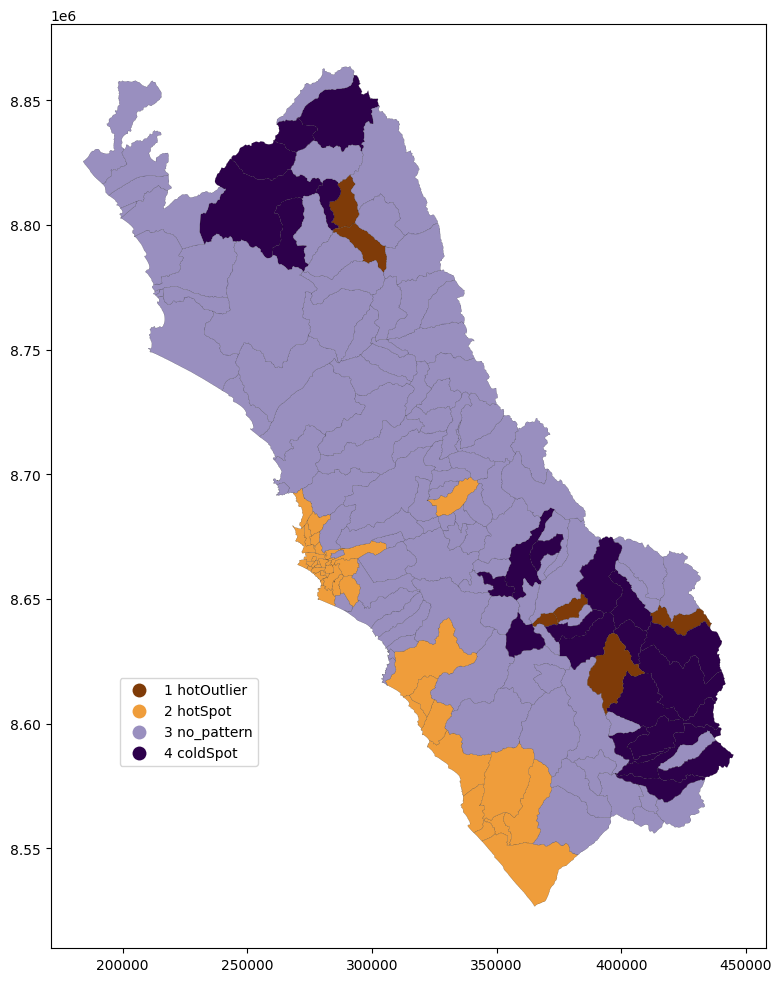

In [86]:
#custom colors- respect the previous order

import matplotlib.pyplot as plt
myColMap = plt.get_cmap('PuOr', 5)


##plot the map

lima.plot(column='HS_lisa',
                categorical=True,
                cmap=myColMap,
                linewidth=0.1,
                edgecolor='k',
                legend=True,
                legend_kwds={'bbox_to_anchor': (0.3, 0.3)},
                figsize=(12,12))

In [87]:
#Save a column for the LISA category, rename the categories as we did in the tutorial. The new column will be "Lisa_queen"


#Redo the LISA MAP, using a  KNN neighborhood  matrix (K = 8).  The new column will be "Lisa_knn8"
#REPORT: Compare if any district does not belong to the same group when using Queen vs. KNN

lima = lima.rename(columns ={'HS_lisa':'Lisa_queen'})
lima.info()
#Redo LISA MAP using KNN8

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 171 entries, 39 to 1871
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   DEPARTAMENTO                  171 non-null    object  
 1   PROVINCIA                     171 non-null    object  
 2   DISTRITO                      171 non-null    object  
 3   ubigeo                        171 non-null    object  
 4   Poblacion                     171 non-null    int64   
 5   IDH2019                       171 non-null    float64 
 6   Educ_sec_comp2019_pct         171 non-null    float64 
 7   NBI2017_pct                   171 non-null    float64 
 8   Viv_sin_serv_hig2017_pct      171 non-null    float64 
 9   geometry                      171 non-null    geometry
 10  Educ_sec_comp2019_pct_lagged  171 non-null    float64 
 11  Lisa_queen                    171 non-null    object  
dtypes: float64(5), geometry(1), int64(1), object(

In [88]:
lima.representative_point()

lima_reference_points=lima.representative_point()

knn8_lima = Graph.build_knn(lima_reference_points, k=8)

knn8_lima_Matrix=toWideMatrix(knn8_lima)
knn8_lima_Matrix

weight                                               ...            \
neighbor   39   40   54   65   71   86   93   102  109  110   ... 1726 1751   
focal                                                         ...             
39          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  1.0  0.0   
40          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
54          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
65          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
71          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
...         ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
1799        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
1804        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  1.0   
1813        1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  1.0  0.0   
1850        0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
1871        0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   

                                                  
neighbor 1781 1783 1797 1799 1804 1813 1850 1871  
focal                                             
39        0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  
40        0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0  
54        1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
65        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
71        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
...       ...  ...  ...  ...  ...  ...  ...  ...  
1799      0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  
1804      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1813      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1850      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1871      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[171 rows x 171 columns]

In [89]:
##this will be used several times:
general_arguments=dict(gdf=lima,node_kws=dict(color='red'), edge_kws=dict(alpha=0.4,color='blue'),zoom_start = 6)


knn8_lima.explore(**general_arguments)

In [90]:
queen_lima=Graph.build_contiguity(lima,rook=False)

# applying our procedure:

queen_lima_Matrix=toWideMatrix(queen_lima)
#queen_lima_Matrix

queen_lima.explore(**general_arguments)

In [91]:
allMx=[queen_lima_Matrix.sum(axis=1),
       knn8_lima_Matrix.sum(axis=1)]
pd.concat(allMx,axis=1)

,0,1
focal,,
39,4.0,8.0
40,12.0,8.0
54,8.0,8.0
65,6.0,8.0
71,5.0,8.0
...,...,...
1799,5.0,8.0
1804,6.0,8.0
1813,5.0,8.0
